# **Install Packages**

In [3]:
# Install libraries for regression analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_validate
import tqdm
import warnings

# **Data Import**

Import the cleaned dataset from the `cleaning_eda.ipynb`.

In [4]:
# Import dataset
df = pd.read_csv("../data/car_price_dataset_cleaned.csv")

In [5]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         2000 non-null   object 
 1   Engine_Size   2000 non-null   float64
 2   Fuel_Type     2000 non-null   object 
 3   Transmission  2000 non-null   object 
 4   Mileage       2000 non-null   int64  
 5   Doors         2000 non-null   int64  
 6   Owner_Count   2000 non-null   int64  
 7   Horsepower    2000 non-null   int64  
 8   Price         2000 non-null   float64
 9   Age           2000 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 156.4+ KB


In [6]:
# Head data
df.head(10)

,Brand,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price,Age
0,Ford,1.2,Hybrid,Manual,180635,4,3,82,34309.25,3
1,Hyundai,3.2,Electric,Manual,35628,2,4,259,55153.60,8
2,BMW,2.2,Diesel,Manual,74672,3,2,333,41894.40,18
3,Hyundai,2.2,Petrol,Automatic,51246,4,4,381,54046.70,9
4,Hyundai,2.4,Electric,Manual,147233,3,4,290,38010.35,14
5,Honda,3.5,Petrol,Automatic,94110,2,4,173,54182.50,3
6,BMW,2.3,Petrol,Manual,7810,2,3,267,52140.50,10
7,BMW,3.9,Petrol,Automatic,195932,4,1,369,61707.40,4
8,BMW,2.6,Electric,Manual,76688,3,1,238,44992.60,16
9,Hyundai,1.3,Electric,Manual,70548,4,4,218,40924.60,4


In [7]:
# Data description
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Brand,2000,6,Toyota,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine_Size,2000.0,NaN,NaN,NaN,2.96755,1.146926,1.0,2.0,2.9,4.0,5.0
Fuel_Type,2000,4,Diesel,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,2000,2,Automatic,1018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mileage,2000.0,NaN,NaN,NaN,100736.9565,56002.915221,5036.0,52365.5,100590.5,148024.5,199904.0
Doors,2000.0,NaN,NaN,NaN,2.988,0.818041,2.0,2.0,3.0,4.0,4.0
Owner_Count,2000.0,NaN,NaN,NaN,2.5325,1.125423,1.0,2.0,3.0,4.0,4.0
Horsepower,2000.0,NaN,NaN,NaN,235.7095,95.59811,70.0,154.0,236.0,319.0,399.0
Price,2000.0,NaN,NaN,NaN,46169.507675,9211.685713,18911.55,39764.0,46112.35,52471.3875,72267.8
Age,2000.0,NaN,NaN,NaN,12.037,5.508248,3.0,7.0,12.0,17.0,21.0


# **Data Preprocessing**

Data preprocessing for linear regression is performed to ensure that the relationships between variables are accurately captured by the algorithm. The data preprocessing steps here include splitting the dataset into training and testing sets, applying an encoder to categorical variables, and scaling numerical variables. 

## **Data Splitting**

The dataset is divided into two parts: an 80% training set and a 20% test set. The target variable is `Price`.

In [8]:
# Split features and target variable
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Preprocessing**

This process involves identifying numerical and categorical variables, encoding the categorical variables using a one-hot encoder, and scaling the numerical variables using `Standardscaler`. This process is performed only on the training set to prevent data leakage.

In [9]:
# Identify numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

In this section, `ColumnTransformer` is used to apply different preprocessing steps to different column types within a single pipeline. `ColumnTransformer` can combine multiple preprocessing steps into a single object, keeping the pipeline clean and reusable, and preventing manual errors in data transformation.

In [10]:
# Transformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ])

- `("num", StandardScaler(), numeric_cols)`: Menerapkan **StandardScaler** pada kolom numerik untuk melakukan normalisasi (mean = 0, std = 1)

- `("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)`: Menerapkan **OneHotEncoder** pada kolom kategorikal untuk mengubah kategori menjadi representasi numerik

# **Modelling**

There are six linear regression algorithms used:

1. Linear Regression (as a baseline)
2. Huber Regression (robust against outliers)
3. Decision Tree (capable of capturing non-linear relationships)
4. Random Forest (an ensemble of many decision trees to reduce the risk of overfitting)
5. Gradient Boosting (a model of decision trees combined sequentially)
6. XGboost (an optimized version of Gradient Boosting)

These six models are defined as a model tuple

In [11]:
# Define models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Huber Regressor": HuberRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

Each model is evaluated using a workflow consisting of:
- Preprocessing (`ColumnTransformer`)
- Model

Evaluation is performed using **5-fold cross-validation** to ensure more reliable results and avoid overfitting.

The models are evaluated using several metrics:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **R² Score**

In [12]:
# Model Iteration

scoring_metrics = {
    'mae' : 'neg_mean_absolute_error',
    'rmse' : 'neg_root_mean_squared_error',
    'r2' : 'r2'
}
results = []

for name, model in tqdm.tqdm(models.items()):
    # Create pipeline
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Cross-validation
    cv_results = cross_validate(
        pipeline, X_train, y_train, cv=5, 
        scoring=scoring_metrics, 
        return_train_score=False)
    
    # Store results
    results.append({
        "Model": name,
        "MAE": -cv_results['test_mae'].mean(),
        "RMSE": -cv_results['test_rmse'].mean(),
        "R2": cv_results['test_r2'].mean()
    })

    print(f"Finished evaluating {name}")

  0%|          | 0/6 [00:00<?, ?it/s]

 17%|█▋        | 1/6 [00:00<00:00,  5.58it/s]

Finished evaluating Linear Regression


 33%|███▎      | 2/6 [00:00<00:01,  3.66it/s]

Finished evaluating Huber Regressor


...

Finished evaluating Random Forest


 83%|████████▎ | 5/6 [00:09<00:02,  2.41s/it]

Finished evaluating Gradient Boosting


100%|██████████| 6/6 [00:09<00:00,  1.64s/it]

Finished evaluating XGBoost


For each model:
1. A pipeline is created (preprocessing + model)
2. Cross-validation is performed
3. The average value of each metric is calculated
4. The results are saved for comparison between models via `results_df`

In [13]:
# Dataset for results
results_df = pd.DataFrame(results)
print(results_df)

               Model          MAE         RMSE        R2
0  Linear Regression  1492.905707  1728.615955  0.964819
1    Huber Regressor  1496.732269  1733.028048  0.964640
2      Decision Tree  3326.236844  4200.090249  0.792338
3      Random Forest  2085.807970  2590.423551  0.921062
4  Gradient Boosting  1711.619623  2072.598826  0.949431
5            XGBoost  2022.459703  2490.933408  0.926878


Based on the modeling results, the baseline Linear Regression model was found to be the best model compared to the others. This is evident from its MAE and RMSE values, which were the lowest among the models, as well as its highest $R^2$ value.

This indicates that:
- The relationship between features and the target tends to be **linear**
- Feature combinations (including one-hot encoded results) are sufficient to capture patterns in the data
- More complex models such as Random Forest and Gradient Boosting do not improve performance, likely due to:
  - Mild overfitting
  - Or data patterns that are not particularly non-linear

# **Model Evaluation**

The model evaluation was performed on the baseline Linear Regression model. The steps included final model fitting, prediction, and visualization of actual values versus predicted values and residuals.

In [20]:
# Final fit for Linear Regression
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower', 'Age'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Brand', 'Fuel_Type', 'Transmission'], dtype='object'))])),
                ('model', LinearRegression())])

In [21]:
# Predict
y_pred = final_model.predict(X_test)

In [25]:
# MAE, RMSE, R2
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")

MAE: 1442.39
RMSE: 1663.28
R2: 0.97


The final Linear Regression model was trained on the full training dataset and evaluated on the test set.

The model achieved slightly better performance compared to cross-validation results. This is expected because:
- The model was trained on more data (full training set)
- Evaluation was performed on a single test split rather than multiple folds

Therefore, cross-validation results remain a more reliable estimate of the model's generalization performance, while the test set evaluation provides a final performance snapshot.

Evaluation metrics from cross-validation:
- MAE = 1492.91
- RMSE = 1728.62
- R² = 0.965

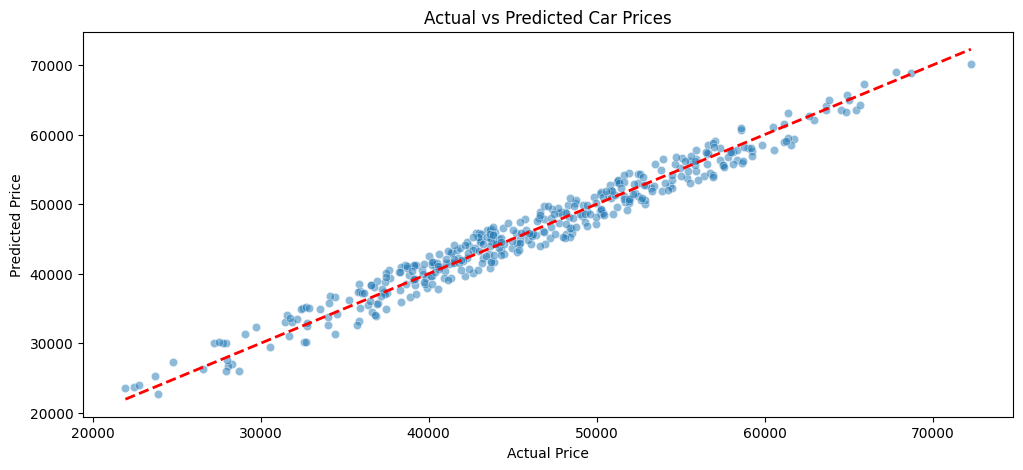

In [23]:
# Actual vs Predicted plot
plt.figure(figsize=(12, 5))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Line for perfect predictions
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

This scatter plot visualizes a comparison between actual car prices and the model’s predicted prices. The red dotted line represents the ideal scenario, where the prediction is 100% accurate.
- The data points (blue) are tightly clustered along the diagonal line. This confirms the $R^2$ value of 0.96, meaning the model is able to explain 96% of the price variation with high accuracy.
- The model demonstrates stable performance across the entire price range, for both budget-category cars (±$20,000) and premium-category cars (±$70,000).

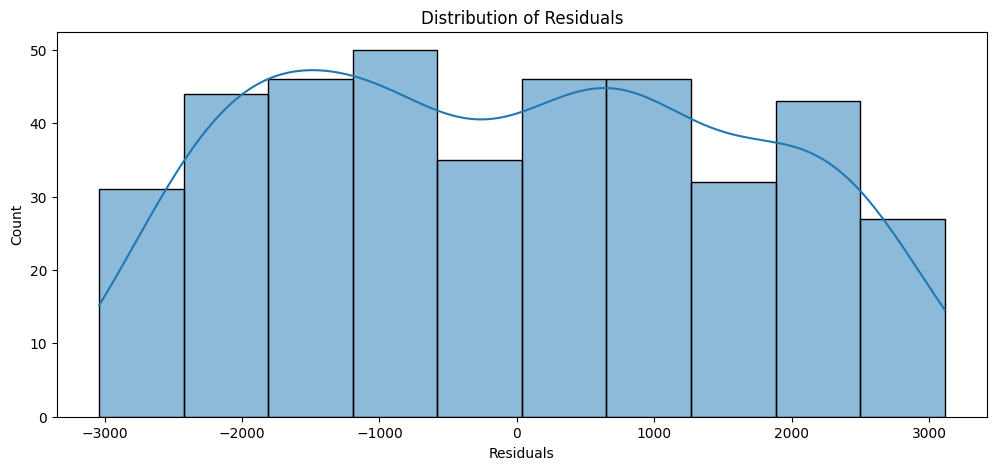

In [24]:
# Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(12, 5))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show()

Based on the residual plot:
- The residual distribution is approximately centered around zero and exhibits a fairly symmetric shape, indicating the absence of systematic bias in predictions. 
- While not perfectly normal, the distribution does not show significant skewness or extreme outliers, suggesting that the model errors are reasonably well-behaved

# **Predict**

To demonstrate the practical usage of the trained model, a sample car specification was created and passed through the pipeline.

In [26]:
# Df for predictions

predict_df = pd.DataFrame({
    'Brand': ['Toyota'],
    'Mileage': [25000],
    'Engine_Size': [2.0],
    'Horsepower': [150],
    'Owner_Count': [3],
    'Doors': [4],
    'Fuel_Type': ['Petrol'],
    'Transmission': ['Automatic'],
    'Age': [3]
})

predicted_price = final_model.predict(predict_df)
print(f"Predicted Price: ${predicted_price[0]:.2f}")


Predicted Price: $47620.16


The model outputs a predicted price based on the input features, showing that the preprocessing and model components are fully integrated. While the true price of this specific example is unknown, the prediction serves as a proof of concept that the model can generalize to new data inputs.

# **Conclusion**

In this project, multiple regression models were evaluated to predict car prices, ranging from simple linear models to more complex ensemble methods.

Among all models, **Linear Regression** achieved the best performance, with the lowest MAE and RMSE, as well as the highest $R^2$ score. This indicates that the model is able to explain a large proportion of the variance in car prices while maintaining relatively low prediction error.

The evaluation metrics suggest that, on average, the model's predictions deviate by approximately the MAE value, which is relatively small compared to the overall price range. The high R² value further confirms that the model captures the underlying relationship between features and the target effectively.

Finally, a sample prediction was performed to demonstrate how the trained pipeline can be applied to new data, confirming that the model is ready for practical use.

Overall, this project highlights that simpler models can outperform more complex ones when the underlying data structure is well-behaved and primarily linear.